<a href="https://colab.research.google.com/github/araoclaudio2-create/Assignment-AI-2/blob/main/Assignment_7_into_to_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_18204/3777693435.py:17: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float

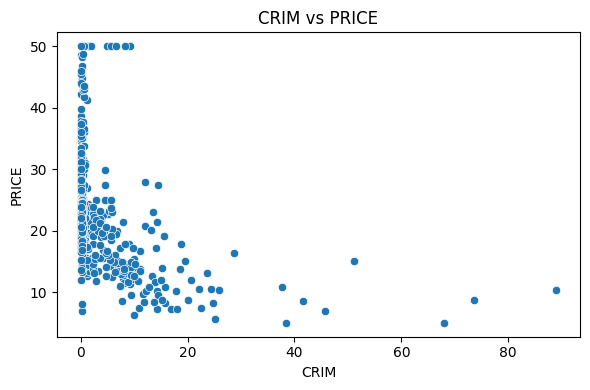

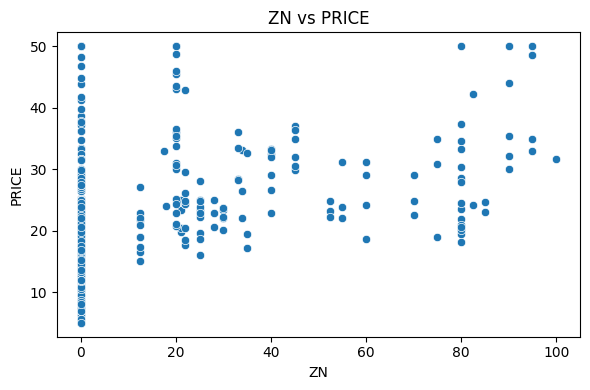

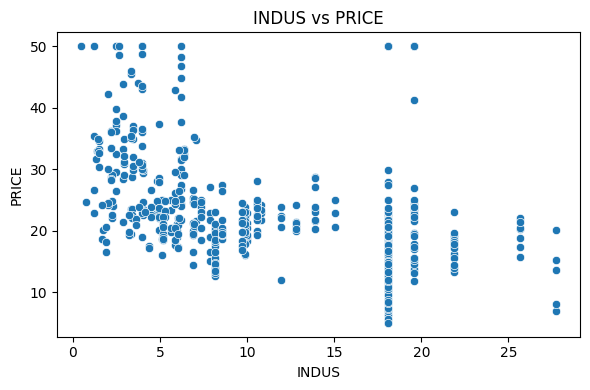

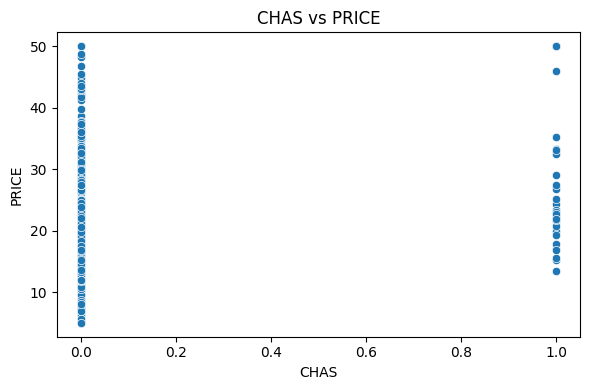

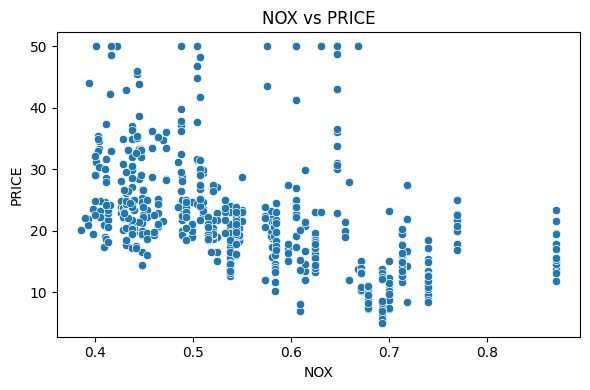

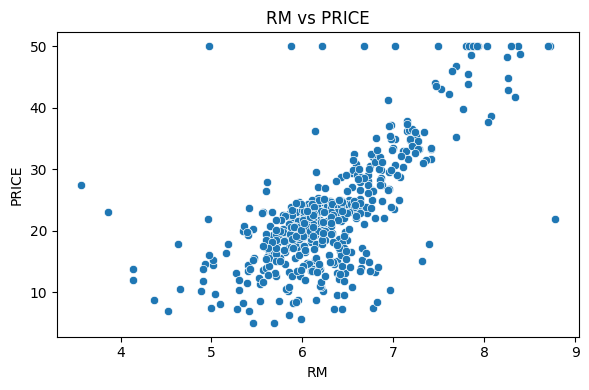

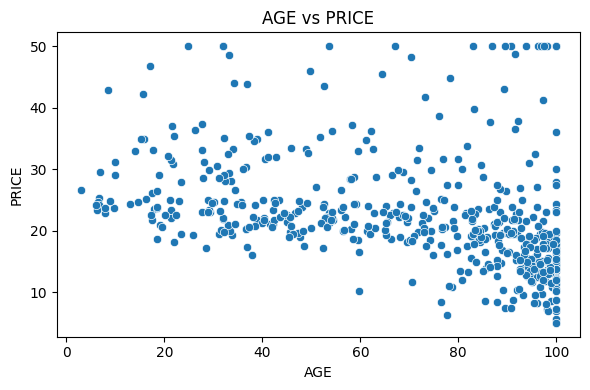

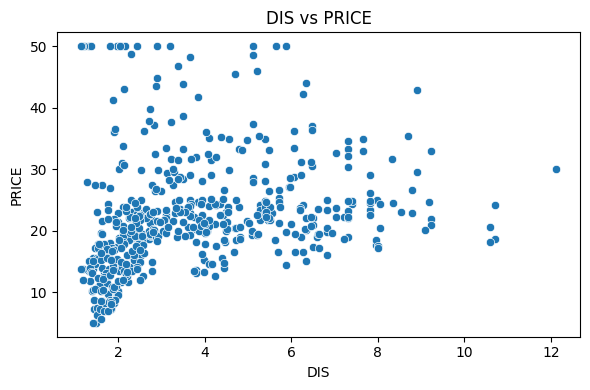

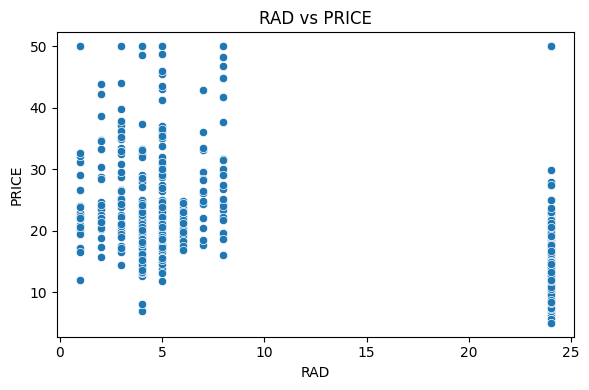

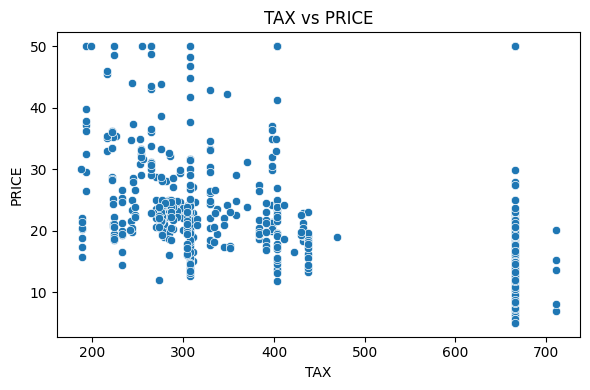

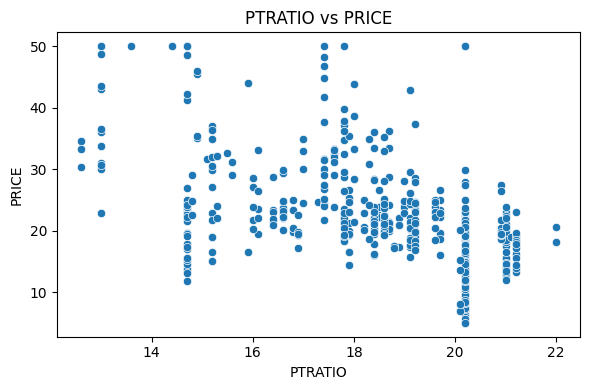

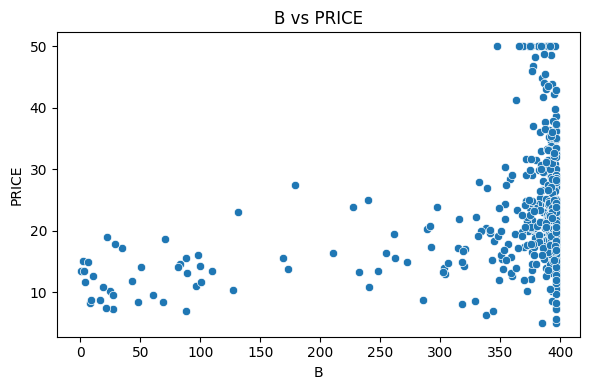

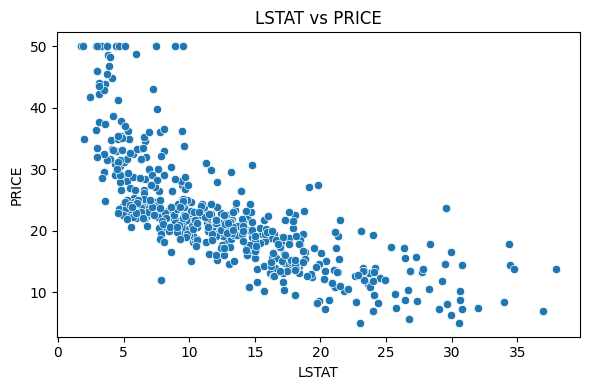


Base Model Performance:
RMSE: 2.8109631609391226
R²: 0.8922527442109116

Best Parameters from Grid Search:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Tuned Model Performance:
RMSE: 2.724436890396961
R²: 0.8987839430903407


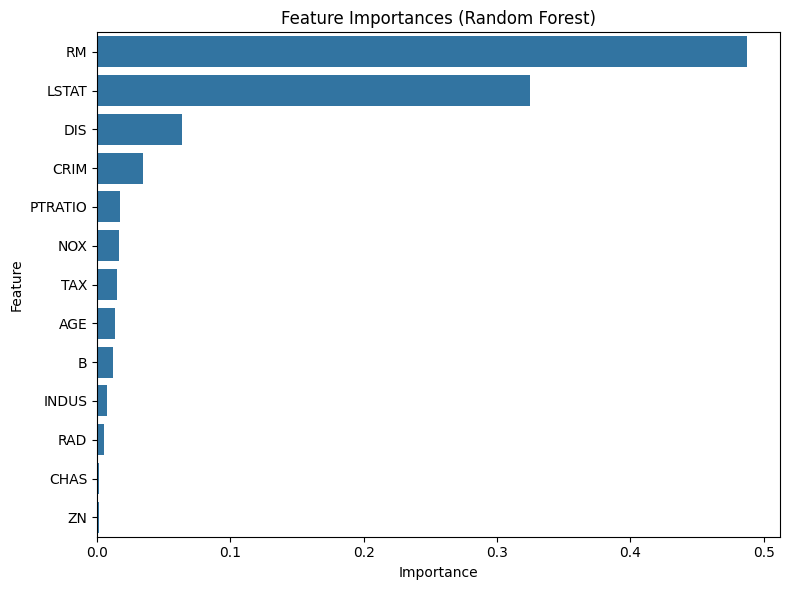


Predicted house price for new sample: 25.9295338006896


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [9]:
# Lesson 7 Assignment – Boston Housing Regression
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from sklearn.datasets import load_boston # Removed due to deprecation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Load data and create DataFrame
# The Boston housing prices dataset has an ethical problem and load_boston has been removed from scikit-learn.
# Fetching the dataset from the original source as suggested by scikit-learn's error message.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define feature names as they were in the original load_boston dataset
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(data, columns=feature_names)
df['PRICE'] = target

# 3. Quick data check
print("First 5 rows:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

# 4.scatter plots for all features vs target
def scatter_all_features(df, target='PRICE'):
    features = df.columns.drop(target)
    for col in features:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f'{col} vs {target}')
        plt.xlabel(col)
        plt.ylabel(target)
        plt.tight_layout()
        plt.show()

scatter_all_features(df)

# 5. Train/test split
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Base model – Random Forest Regressor
base_model = RandomForestRegressor(random_state=42)
base_model.fit(X_train, y_train)

# 7. Evaluation of base model
y_pred_base = base_model.predict(X_test)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("\nBase Model Performance:")
print("RMSE:", rmse_base)
print("R²:", r2_base)

# 8. Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters from Grid Search:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# 9. Evaluation of tuned model
y_pred_best = best_model.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("\nTuned Model Performance:")
print("RMSE:", rmse_best)
print("R²:", r2_best)

# 10. Feature importance plot
importances = best_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 11. Predict on new data example
# Example new sample (must match feature order exactly)
# [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT]
new_sample = np.array([[0.1, 18.0, 2.31, 0, 0.54, 6.5, 65.0, 4.09, 1.0, 300.0, 15.0, 390.0, 5.0]])

predicted_price = best_model.predict(new_sample)
print("\nPredicted house price for new sample:", predicted_price[0])